len(uwnd_anom time) = 3036
len(df date)        = 3036
len(common_time)    = 3036
len(uwnd_sel time) = 3036
len(node_vals)     = 3036
<xarray.DataArray 'uwnd' (node: 9, lat: 33, lon: 105)> Size: 125kB
array([[[-0.45131955, -0.44739476, -0.4096829 , ...,  0.24074197,
          0.15245908,  0.00989493],
        [-0.34966537, -0.32006   , -0.28914604, ...,  0.14466603,
          0.14683126,  0.08119113],
        [-0.33561513, -0.2517807 , -0.20015557, ...,  0.29458708,
          0.2940072 ,  0.24297078],
        ...,
        [-0.49099496, -0.57659405, -0.6450952 , ...,  0.08077542,
          0.09725977,  0.02310719],
        [-0.19274573, -0.27029282, -0.33180285, ..., -0.13653126,
         -0.15641768, -0.22896634],
        [ 0.2660912 ,  0.23340401,  0.20701924, ..., -0.4281882 ,
         -0.42354715, -0.42341566]],

       [[-0.16943668, -0.18497497, -0.2532769 , ..., -0.99864465,
         -0.79095036, -0.586103  ],
        [-0.13853137, -0.18100262, -0.25917745, ..., -0.8836882 ,
     

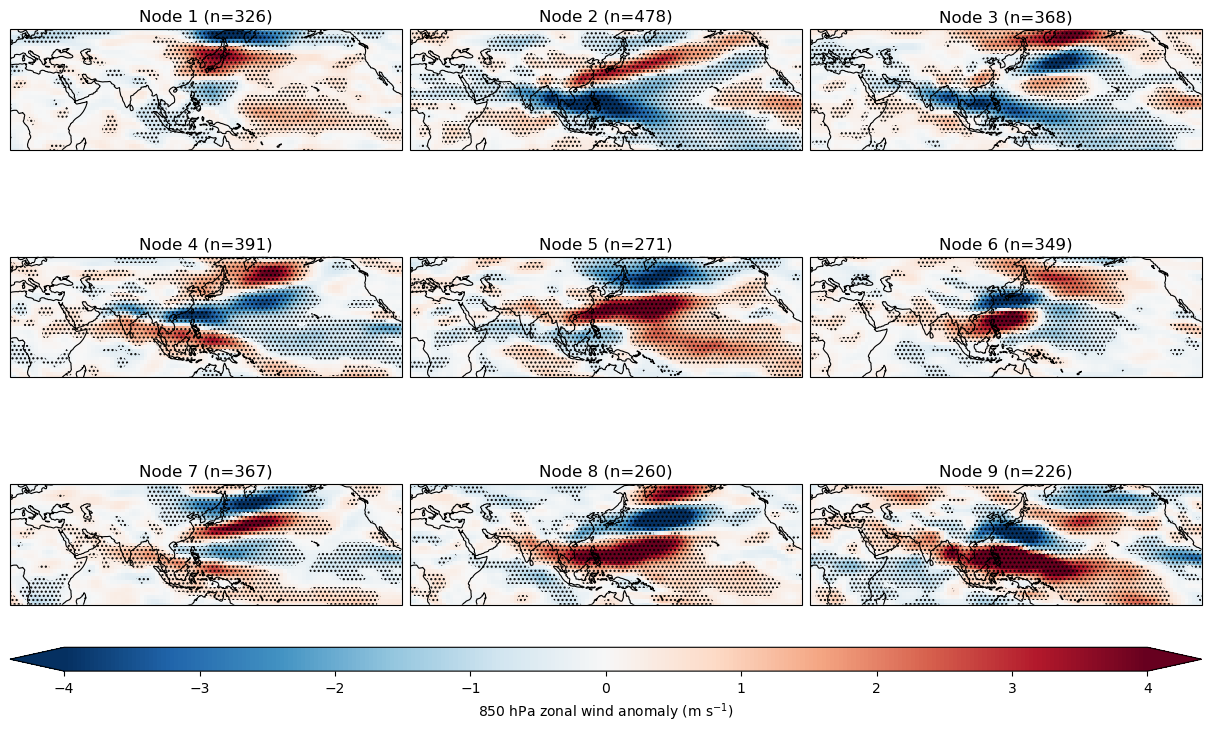

In [1]:
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "scripts").exists() and (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError(
        "Could not locate the repository root. Start Jupyter from this repository or one of its subdirectories."
    )

REPO_ROOT = find_repo_root(Path.cwd())
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
OUTPUT_DIR = REPO_ROOT / "outputs" / "som_u850"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# =========================================================
# 0) input paths
# =========================================================
som_csv = OUTPUT_DIR / "som_daily_assignment.csv"
uwnd_file = PROCESSED_DIR / "uwnd_z850_jja_1991_2023.nc"
out_nc = OUTPUT_DIR / "u850_anom_node_composites.nc"
out_fig = OUTPUT_DIR / "u850_anom_node_composites_sig2.png"

uwnd_varname = "uwnd"
extent = [0, 260, -20, 60]
nodes_all = np.arange(1, 10)

# =========================================================
# 1) SOM daily assignments
# =========================================================
df = pd.read_csv(som_csv)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df[df["node"].between(1, 9)].copy()
df = df.sort_values("date").drop_duplicates(subset="date")

# =========================================================
# 2) UWND data
# =========================================================
ds = xr.open_dataset(uwnd_file)
uwnd = ds[uwnd_varname]

rename_dict = {}
if "latitude" in uwnd.dims:
    rename_dict["latitude"] = "lat"
if "longitude" in uwnd.dims:
    rename_dict["longitude"] = "lon"
if rename_dict:
    uwnd = uwnd.rename(rename_dict)

uwnd = uwnd.squeeze(drop=True)
uwnd = uwnd.assign_coords(time=pd.to_datetime(uwnd["time"].values).normalize())
uwnd = uwnd.transpose("time", "lat", "lon")

if uwnd["lat"].values[0] > uwnd["lat"].values[-1]:
    uwnd = uwnd.sortby("lat")
if uwnd["lon"].values[0] > uwnd["lon"].values[-1]:
    uwnd = uwnd.sortby("lon")

uwnd = uwnd.sel(
    lon=slice(extent[0], extent[1]),
    lat=slice(extent[2], extent[3]),
)

# =========================================================
# 3) Daily anomaly
# =========================================================
clim = uwnd.groupby("time.dayofyear").mean("time")
uwnd_anom = uwnd.groupby("time.dayofyear") - clim

# =========================================================
# 4) Common dates
# =========================================================
common_time = np.intersect1d(uwnd_anom["time"].values, df["date"].values)

print("len(uwnd_anom time) =", uwnd_anom.sizes["time"])
print("len(df date)        =", len(df))
print("len(common_time)    =", len(common_time))

if len(common_time) == 0:
    raise ValueError("No common dates were found between the SOM CSV and the uwnd dataset.")

uwnd_sel = uwnd_anom.sel(time=common_time)

node_map = (
    df.set_index("date")["node"]
      .reindex(pd.to_datetime(common_time))
)

valid = ~node_map.isna().to_numpy()
uwnd_sel = uwnd_sel.isel(time=valid)
node_vals = node_map.to_numpy()[valid].astype(int)

print("len(uwnd_sel time) =", uwnd_sel.sizes["time"])
print("len(node_vals)     =", len(node_vals))

if uwnd_sel.sizes["time"] == 0:
    raise ValueError("uwnd_sel has zero time samples after aligning dates.")

# =========================================================
# 5) Node coordinate
# =========================================================
uwnd_sel = uwnd_sel.assign_coords(node=("time", node_vals))

# =========================================================
# 6) Node composites / std / n / se
# =========================================================
comp = uwnd_sel.groupby("node").mean("time")
std = uwnd_sel.groupby("node").std("time")
n = uwnd_sel.groupby("node").count("time")

comp = comp.reindex(node=nodes_all)
std = std.reindex(node=nodes_all)
n = n.reindex(node=nodes_all)

se = std / np.sqrt(n)
sig2 = (np.abs(comp) >= 2.0 * se).fillna(False)

xr.Dataset(
    {
        "uwnd_anom_comp": comp,
        "uwnd_anom_std": std,
        "uwnd_anom_n": n,
        "uwnd_anom_se": se,
        "uwnd_anom_sig2": sig2.astype(np.int8),
        "uwnd_climatology": clim,
    }
).to_netcdf(out_nc)

print(comp)
print(n)

# =========================================================
# 7) Plot
# =========================================================
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 8),
    layout="constrained",
    subplot_kw={"projection": proj}
)

pcm = None

for i, ax in enumerate(axes.flat, start=1):
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    da = comp.sel(node=i).squeeze(drop=True)
    mask = sig2.sel(node=i).squeeze(drop=True)
    node_n = int(np.nanmax(n.sel(node=i).values)) if np.isfinite(n.sel(node=i).values).any() else 0

    if np.isfinite(da.values).any():
        pcm = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            add_colorbar=False,
            cmap="RdBu_r",
            vmin=-4,
            vmax=4,
            extend="both",
        )

        ax.contourf(
            da["lon"].values,
            da["lat"].values,
            mask.astype(int).values,
            levels=[0.5, 1.5],
            hatches=["...."],
            colors="none",
            transform=ccrs.PlateCarree(),
        )

    ax.coastlines(linewidth=0.8)
    ax.set_title(f"Node {i} (n={node_n})")

if pcm is not None:
    cbar = fig.colorbar(
        pcm,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        aspect=50,
        extend="both",
    )
    cbar.set_label("850 hPa zonal wind anomaly (m s$^{-1}$)")

plt.savefig(out_fig, dpi=180, bbox_inches="tight")
plt.show()
